## ASE sandbox
(atomic simulation environment) 
building structures, visualization, EMT relaxation

#### 1. imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ase import Atoms
from ase.build import bulk, molecule, surface, add_adsorbate
from ase.visualize.plot import plot_atoms
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.io import write
from ase.eos import EquationOfState

#### 2. building structures

**terms**
* bulk structure: infinite in 3 dims (x, y z) w/ periodic boundary conds
* slab structure: infinite in 2 dims (x, y) w/ surface z

In [2]:
# Atoms obj is list of atoms w/ positions, unit cell type, unit cell length (PBC)

# fcc copper bulk crystal
cu_single = bulk('Cu', 'fcc', a=3.6)  # a in Angstroms
print(cu_single)
print('Positions:', cu_single.positions)
print('Cell:', cu_single.cell)
print('PBC:', cu_single.pbc)  # gives whether system is periodic in each direction


Atoms(symbols='Cu', pbc=True, cell=[[0.0, 1.8, 1.8], [1.8, 0.0, 1.8], [1.8, 1.8, 0.0]])
Positions: [[0. 0. 0.]]
Cell: Cell([[0.0, 1.8, 1.8], [1.8, 0.0, 1.8], [1.8, 1.8, 0.0]])
PBC: [ True  True  True]


In [3]:
# water molecule (no periodic boundaries)
h2o = molecule('H2O')
print(h2o)
print('Symbols:', h2o.get_chemical_symbols())
print('Positions:', h2o.positions)

Atoms(symbols='OH2', pbc=False)
Symbols: ['O', 'H', 'H']
Positions: [[ 0.        0.        0.119262]
 [ 0.        0.763239 -0.477047]
 [ 0.       -0.763239 -0.477047]]


#### 3. visualization

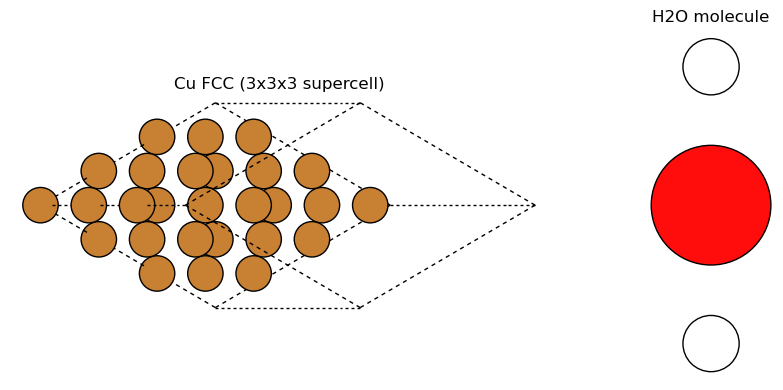

In [4]:
# inline 2D rendering w/ plot_atoms

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  
# 1 row, 2 cols of subplots, total fig. is 10 x 4 inches
# axes[0] is left fig., axes[1] is right

# cu supercell (cell repeated 3x in each dir.)
cu_super = cu_single.repeat([3, 3, 3])
plot_atoms(cu_super, axes[0], radii=0.5, rotation=('45x,45y,0z'))  # radii is drawn atom size as fraction of covalent radius
axes[0].set_title('Cu FCC (3x3x3 supercell)')
axes[0].axis('off')

# h20
plot_atoms(h2o, axes[1], radii=0.5)
axes[1].set_title('H2O molecule')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# 3d viewer, open in VESTA

from ase.io import write

In [6]:
# write('cu.xyz', cu_super)
# write('cu.cif', cu_super)  # export to CIF format

#### 4. adding a calculator

calculator computes energy, forces, stress for given Atoms config.

EMT (effective medium theory): approximates energy of a metal atom based on local electron density around it. works for fcc metals (Cu, Au, Al, Ni, Pd, Pt, Ag) only

In [7]:
cu_single.calc = EMT()  # attach calculator

print('Energy (eV):', cu_single.get_potential_energy())
print('Forces (eV/A):', cu_single.get_forces())  # eV/Angstrom
print('Stresses (eV/A^3):', cu_single.get_stress())  # eV/Angstrom, bulk stress


Energy (eV): -0.00668876868578927
Forces (eV/A): [[-3.29568555e-16 -2.84085544e-15  3.43002604e-15]]
Stresses (eV/A^3): [ 7.00014127e-03  7.00014127e-03  7.00014127e-03 -1.67811578e-16
  1.38004681e-16 -6.30394279e-17]


#### 5. structure relaxation

relaxation: minimize forces by moving atoms
BFGS used here, optimization loop calls calc repeatedly

In [8]:
# perturb Cu lattice slightly so there's something to relax
cu_relax = bulk('Cu', 'fcc', a=3.7)  # slightly wrong lattice constant
cu_relax.calc = EMT()

print('Energy before relaxation:', cu_relax.get_potential_energy(), 'eV')

opt = BFGS(cu_relax, logfile=None)
opt.run(fmax=0.01)  # converge until max force on any atom < 0.01 eV/A

print('Energy after relaxation: ', cu_relax.get_potential_energy(), 'eV')
print('Final cell:', cu_relax.cell)

# no energy difference b/c there's just 1 atom here

Energy before relaxation: 0.0302960771489591 eV
Energy after relaxation:  0.0302960771489591 eV
Final cell: Cell([[0.0, 1.85, 1.85], [1.85, 0.0, 1.85], [1.85, 1.85, 0.0]])


In [9]:
# add cell degrees of freedom to relax the 1-atom primitive cell
from ase.filters import FrechetCellFilter

cu_relax = bulk('Cu', 'fcc', a=3.7)
cu_relax.calc = EMT()

print('Energy before relaxation:', cu_relax.get_potential_energy(), 'eV')

opt = BFGS(FrechetCellFilter(cu_relax), logfile=None)
opt.run(fmax=0.01)

print('Energy after relaxation: ', cu_relax.get_potential_energy(), 'eV')
print('Relaxed cell:', cu_relax.cell)

Energy before relaxation: 0.0302960771489591 eV
Energy after relaxation:  -0.0070357400495186795 eV
Relaxed cell: Cell([[2.733258062364282e-16, 1.7951483465462954, 1.7951483465462963], [1.795148346546295, 5.3249640258344464e-17, 1.7951483465462963], [1.7951483465462965, 1.7951483465462963, 1.4841969735049785e-16]])


In [10]:
# relax 27-atom super cell

cu_super = bulk('Cu', 'fcc', a=3.7).repeat([3, 3, 3])
cu_super.calc = EMT()

print('Energy before relaxation:', cu_super.get_potential_energy(), 'eV')

opt = BFGS(FrechetCellFilter(cu_super), logfile=None)
opt.run(fmax=0.01)

print('Energy after relaxation:', cu_super.get_potential_energy(), 'eV')
print('Relaxed cell:', cu_super.cell)

Energy before relaxation: 0.8179940830217678 eV
Energy after relaxation: -0.1899478386436737 eV
Relaxed cell: Cell([[-5.546841225564808e-16, 5.385698129320658, 5.385698129319975], [5.385698129320794, -4.4007435375164407e-14, 5.385698129319986], [5.385698129320927, 5.385698129320701, -1.0913042751058611e-14]])


#### 6. equation of state

In [11]:
volumes = []
energies = []

for scale in np.linspace(0.94, 1.06, 13):  # scanning ±6% around the reference lattice constant
    atoms = bulk('Cu', 'fcc', a=3.6)
    atoms.set_cell(atoms.cell * scale, scale_atoms=True)
    atoms.calc = EMT()
    volumes.append(atoms.get_volume())
    energies.append(atoms.get_potential_energy())

eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()

# bulk modulus B comes out in eV/Ang^3; convert to GPa
B_GPa = B / 6.241509e-3  # 1 eV/Ang^3 = 160.218 GPa
from ase.units import kJ
print(f'Equilibrium volume: {v0:.3f} Ang^3')
print(f'Equilibrium energy: {e0:.4f} eV')
print(f'Bulk modulus:       {B / kJ * 1e24:.1f} GPa')

Equilibrium volume: 11.569 Ang^3
Equilibrium energy: -0.0068 eV
Bulk modulus:       133.2 GPa


#### 7. surface + adsorbate

In [12]:
# fcc (111) is conventional starting point, most stable surface for fcc metals
# FixAtoms freezes the location of certain atoms so the optimizer can't move them during relaxation
#   fix the bottom layers of the surface slab to represent unaffected bulk

from ase.build import fcc111, add_adsorbate
from ase.constraints import FixAtoms

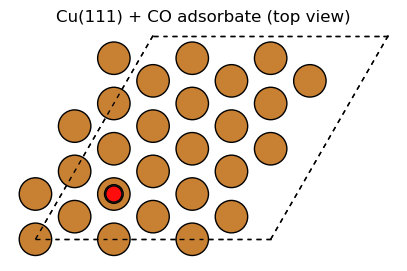

Atoms in slab: 29
Chemical formula: CCu27O


In [13]:
# Cu(111) surface slab: 3 layers, vacuum of 10 Ang above
slab = fcc111('Cu', size=(3, 3, 3), vacuum=10.0)

# fix bottom layer
mask = [atom.tag == 3 for atom in slab]  # tag==3 is bottom layer
slab.set_constraint(FixAtoms(mask=mask))

# add a CO molecule on a hcp hollow site
from ase.build import molecule
add_adsorbate(slab, molecule('CO'), height=2.0, position='hcp')

# visualize
fig, ax = plt.subplots(figsize=(5, 6))
plot_atoms(slab, ax, rotation=('0x,0y,0z'), radii=0.4)
ax.set_title('Cu(111) + CO adsorbate (top view)')
ax.axis('off')
plt.show()

print('Atoms in slab:', len(slab))
print('Chemical formula:', slab.get_chemical_formula())


In [ ]:
# open in VESTA
# write('slab_co.cif', slab)

#### 8. swapping calculators (EMT --> MACE)

In [16]:

from mace.calculators import mace_mp

In [17]:
calc = mace_mp(model="medium", dispersion=False, default_dtype="float32")
cu_single.calc = calc  # attach calculator

print('Energy (eV):', cu_single.get_potential_energy())
print('Forces (eV/A):', cu_single.get_forces())  # eV/Angstrom
print('Stresses (eV/A^3):', cu_single.get_stress())  # eV/Angstrom, bulk stress

Downloading: 100.0% (42.4 MB / 42.4 MB)
Cached MACE model to /Users/zschwab/.cache/mace/20231203mace128L1_epoch199model
Using Materials Project MACE for MACECalculator with /Users/zschwab/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/Users/zschwab/miniconda3/envs/mlip/lib/python3.11/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Energy (eV): -4.082337379455566
Forces (eV/A): [[0. 0. 0.]]
Stresses (eV/A^3): [-2.0202383e-02 -2.0202342e-02 -2.0202298e-02 -9.7023334e-10
  1.0220282e-09  7.5959745e-11]


In [ ]:
print("""
    From EMT:
    Energy (eV): -0.00668876868578927
    Forces (eV/A): [[-3.29568555e-16 -2.84085544e-15  3.43002604e-15]]
    Stresses (eV/A^3): [ 7.00014127e-03  7.00014127e-03  7.00014127e-03 -1.67811578e-16
    1.38004681e-16 -6.30394279e-17]
    """)

# EMT vs. MACE
# energy: EMT's zero is energy of atoms in bulk env, so deviations from this are small for a nearly perfect crystal
#         MACE is trained on DFT, which uses energy of isolated atoms in vacuum (ie. cohesive energy)
# forces: both ~0 b/c near-perfect, symmetric crystal
# stresses: + = tension (pulling apart), - = compression
#           EMT says lattice wants to compress, MACE says lattice wants to expand


    From EMT:
    Energy (eV): -0.00668876868578927
    Forces (eV/A): [[-3.29568555e-16 -2.84085544e-15  3.43002604e-15]]
    Stresses (eV/A^3): [ 7.00014127e-03  7.00014127e-03  7.00014127e-03 -1.67811578e-16
    1.38004681e-16 -6.30394279e-17]
    


In [ ]:
# checking EOS w/ MACE as calculator

volumes = []
energies = []

for scale in np.linspace(0.94, 1.06, 13):  # scanning ±6% around the reference lattice constant
    atoms = bulk('Cu', 'fcc', a=3.6)
    atoms.set_cell(atoms.cell * scale, scale_atoms=True)
    atoms.calc = calc  # MACE
    volumes.append(atoms.get_volume())
    energies.append(atoms.get_potential_energy())

eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()

# bulk modulus B comes out in eV/Ang^3; convert to GPa
B_GPa = B / 6.241509e-3  # 1 eV/Ang^3 = 160.218 GPa
from ase.units import kJ
print(f'Equilibrium volume: {v0:.3f} Ang^3')
print(f'Equilibrium energy: {e0:.4f} eV')
print(f'Bulk modulus:       {B / kJ * 1e24:.1f} GPa') 

Equilibrium volume: 11.915 Ang^3
Equilibrium energy: -4.0848 eV
Bulk modulus:       144.0 GPa


In [21]:
# compare experimental and computed bulk modulus values

exp_value = 140.0  # GPa
mace_value = 144.0
diff = mace_value - exp_value
pct_diff = (diff / exp_value) * 100
print(f'Difference: {diff:.1f} GPa ({pct_diff:.1f}%) greater than experimental value')

Difference: 4.0 GPa (2.9%) greater than experimental value
